In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

TRAIN_PATH = os.path.join(DATASET_PATH, "train", "images")
VAL_PATH = os.path.join(DATASET_PATH, "validation", "images")

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)

Train path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\train\images
Validation path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\validation\images


In [3]:
print("Train folder exists:", os.path.exists(TRAIN_PATH))
print("Validation folder exists:", os.path.exists(VAL_PATH))

Train folder exists: True
Validation folder exists: True


In [4]:
classes = sorted([
    folder for folder in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, folder))
])

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, "→", class_name)

Classes:
0 → crazing
1 → inclusion
2 → patches
3 → pitted_surface
4 → rolled-in_scale
5 → scratches


In [5]:
def count_images(folder_path):
    counts = {}

    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)

        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        counts[class_name] = len(image_files)

    return counts


train_counts = count_images(TRAIN_PATH)
val_counts = count_images(VAL_PATH)

print("Training images:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nValidation images:")
for class_name, count in val_counts.items():
    print(f"{class_name}: {count}")

Training images:
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240

Validation images:
crazing: 60
inclusion: 60
patches: 60
pitted_surface: 60
rolled-in_scale: 60
scratches: 60


In [6]:
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())

print("Total training images:", total_train)
print("Total validation images:", total_val)
print("Total images:", total_train + total_val)

Total training images: 1440
Total validation images: 360
Total images: 1800


Class: crazing
Image name: crazing_1.jpg
Image size: (200, 200)
Image mode: RGB


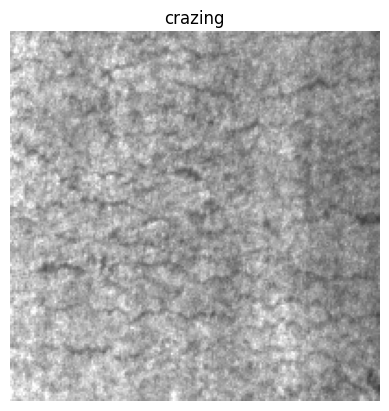

In [7]:
class_name = classes[0]

class_path = os.path.join(TRAIN_PATH, class_name)

image_files = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

first_image_path = os.path.join(class_path, image_files[0])

image = Image.open(first_image_path)

print("Class:", class_name)
print("Image name:", image_files[0])
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.imshow(image)
plt.title(class_name)
plt.axis("off")
plt.show()

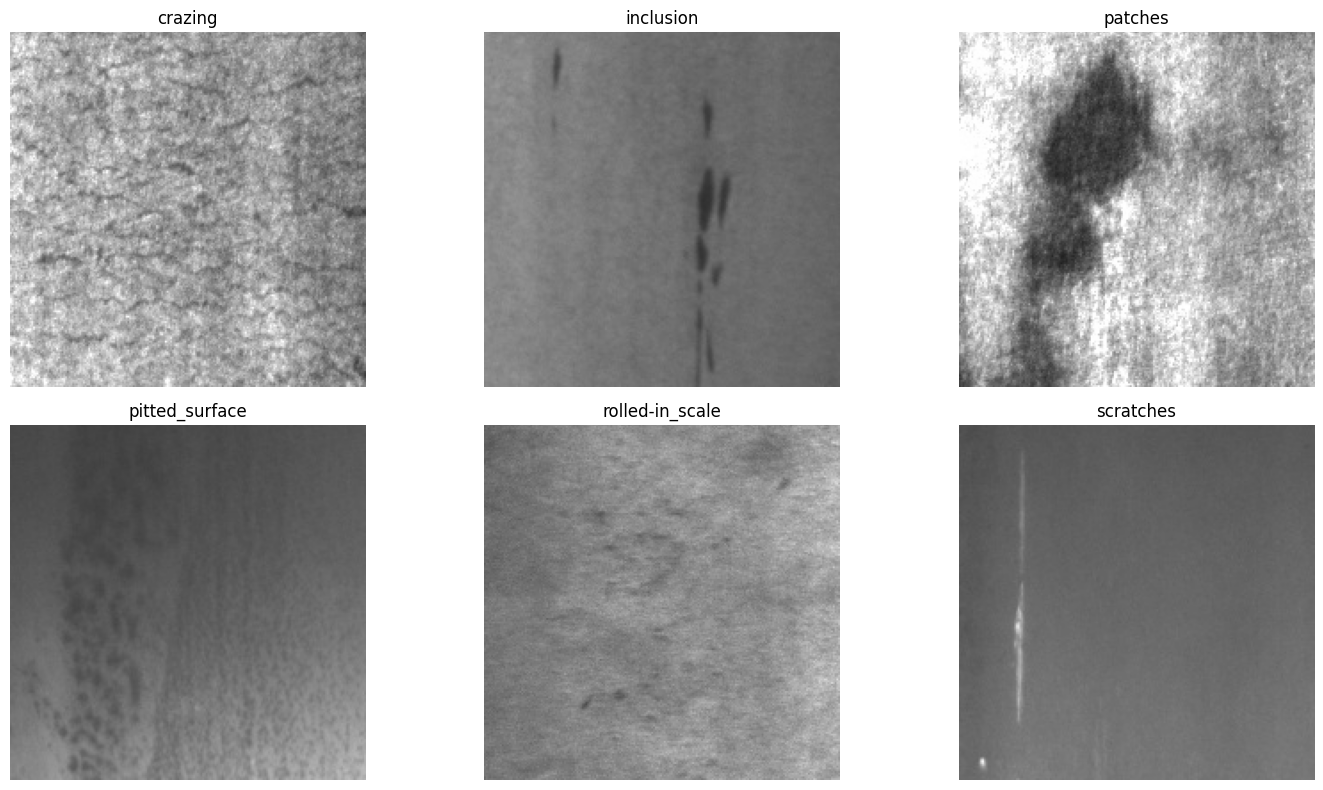

In [8]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_PATH, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

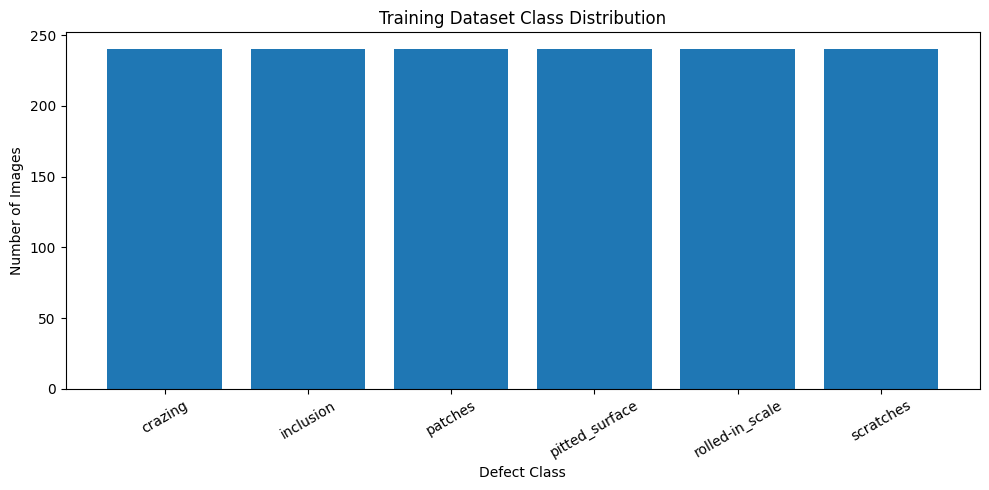

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()